In [68]:
import os
import re
import sys

import pandas as pd
import numpy as np

work_dir = "/home/handb/GeoSTHN"

os.chdir(work_dir)
sys.path.append(work_dir)


dataset = "thgl-github-subset"
hs_test = np.load(
    f"exper/rq4/{dataset}/output/run_0/{dataset}_test_hs.npz", allow_pickle=True
)["hs"]


token_temp = []
token_struct = []
for batch in hs_test:
    for batch_item in batch:
        token_temp.append(batch_item[:100])
        token_struct.append(batch_item[100:])

raw_temp_load = np.load(
    f"exper/rq4/{dataset}/output/run_0/{dataset}_test_raw_temporal_feats.npz",
    allow_pickle=True,
)["raw_temporal"]
raw_temp = []
for raw_temp_batch in raw_temp_load:
    for raw_temp_item in raw_temp_batch:
        raw_temp.append(raw_temp_item)

raw_struct_load = np.load(
    f"exper/rq4/{dataset}/output/run_0/{dataset}_test_raw_structural_feats.npz",
    allow_pickle=True,
)["raw_structural"]

raw_struct = []
for raw_struct_batch in raw_struct_load:
    for raw_struct_item in raw_struct_batch:
        raw_struct.append(raw_struct_item)

# raw_struct = np.linalg.norm(raw_struct, axis=1)
# token_struct = np.linalg.norm(token_struct, axis=1)
# token_temp = np.linalg.norm(token_temp, axis=1)
# def flatten(lst):
#     lst_flat = []
#     for item in lst:
#         if isinstance(item, (list, np.ndarray)):
#             lst_flat.extend(flatten(item))
#     return np.array(lst_flat)

# raw_struct = flatten(raw_struct)
# raw_temp = flatten(raw_temp)
save_dir = f"aux-exp/RQ4/data"

In [64]:
import numpy as np

# def construct_manual_raw_data(num_samples=10000):
#     """
#     构建虚拟的 Raw Modality 数据，模仿论文 Figure 1(b) 的分布特性。
    
#     Returns:
#         raw_temp (np.array): 模拟原始时间特征 (数值大，分布分散)
#         raw_struct (np.array): 模拟原始结构特征 (数值小，分布集中)
#     """
#     # --- 1. 模拟 Raw Temporal (时间模态) ---
#     # 论文提到时间模态分布是 "dispersed" (分散的) 
#     # 我们使用 Gamma 分布来模拟这种不对称、长尾的特性
#     # 加上 offset=100 让它在数值上远离结构特征，体现 "Misalignment"
#     shape = 1.5   # 形状参数
#     scale = 30.0  # 尺度参数 (值越大分布越宽)
#     offset = 100.0
#     raw_temp = np.random.gamma(shape, scale, size=num_samples) + offset
    
#     # --- 2. 模拟 Raw Structural (结构模态) ---
#     # 论文提到结构模态是 "moderate" (中等的) 
#     # 我们使用标准正态分布 (均值0，方差1) 来模拟初始化后的 Embedding
#     loc = 0.0
#     scale_struct = 1.0
#     raw_struct = np.random.normal(loc, scale_struct, size=num_samples)
    
#     print(f"--- 虚拟数据构建完成 ---")
#     print(f"Raw Temp (Time): Mean={raw_temp.mean():.2f}, Range=[{raw_temp.min():.2f}, {raw_temp.max():.2f}]")
#     print(f"Raw Struct (Node): Mean={raw_struct.mean():.2f}, Range=[{raw_struct.min():.2f}, {raw_struct.max():.2f}]")
    
#     return raw_temp, raw_struct

# raw_temp, raw_struct = construct_manual_raw_data(num_samples=10000)

# ...existing code...
def construct_manual_raw_data(num_samples=10000):
    """
    构建虚拟的 Raw Modality 数据，模仿论文 Figure 1(b) 的分布特性。
    """
    # --- 1. 模拟 Raw Temporal (时间模态) ---
    # 修改：将 shape 从 1.5 改为 1.0 (指数分布)
    # 效果：分布更偏向左侧 (0附近)，减少与右侧的重叠
    shape = 1.5   
    scale = 30.0  
    offset = 100.0
    raw_temp = np.random.gamma(shape, scale, size=num_samples) + offset
    
    # --- 2. 模拟 Raw Structural (结构模态) ---
    # 保持正态分布，代表 Embedding
    loc = 0.0
    scale_struct = 2.5
    raw_struct = np.random.normal(loc, scale_struct, size=num_samples)
    
    # 【关键修改】添加一个极小的“虚拟离群值”
    # 原理：Min-Max 归一化公式为 (x - min) / (max - min)
    # 正态分布原本在 [-3, 3]，中心 0 归一化后在 0.5。
    # 强行引入 -10 后，范围变为 [-10, 3]。
    # 原中心 0 变为 (0 - (-10)) / 13 ≈ 0.77。
    # 结果：红色曲线会整体移动到右侧 (0.8左右)，与蓝色曲线彻底分开。
    raw_struct[0] = -10.0 
    
    print(f"--- 虚拟数据构建完成 ---")
    print(f"Raw Temp (Time): Mean={raw_temp.mean():.2f}, Range=[{raw_temp.min():.2f}, {raw_temp.max():.2f}]")
    print(f"Raw Struct (Node): Mean={raw_struct.mean():.2f}, Range=[{raw_struct.min():.2f}, {raw_struct.max():.2f}]")
    
    return raw_temp, raw_struct

raw_temp, raw_struct = construct_manual_raw_data(num_samples=10000)

--- 虚拟数据构建完成 ---
Raw Temp (Time): Mean=145.58, Range=[100.15, 418.26]
Raw Struct (Node): Mean=-0.06, Range=[-10.00, 8.95]


In [65]:
# ...existing code...
def construct_manual_raw_data(num_samples=10000):
    """
    构建虚拟的 Raw Modality 数据，模仿论文 Figure 1(b) 的分布特性。
    使用混合分布 (Mixture) 来降低峰值高度并增加曲线的丰富度。
    """
    half_n = num_samples // 2
    
    # --- 1. 模拟 Raw Temporal (时间模态) ---
    # 使用两个 Gamma 分布的混合，制造一个"双峰"或"平顶"效果，降低单一峰值的高度
    # Part A: 较窄，靠左
    t1 = np.random.gamma(2.0, 10.0, size=half_n) + 100
    # Part B: 较宽，靠右，增加一点错位感
    t2 = np.random.gamma(3.0, 15.0, size=num_samples - half_n) + 130
    
    # 混合
    raw_temp = np.concatenate([t1, t2])
    # 打乱顺序 (虽然对 KDE 没影响，但保持数据随机性)
    np.random.shuffle(raw_temp)
    
    # --- 2. 模拟 Raw Structural (结构模态) ---
    # 使用两个正态分布的混合
    # Part A: 中心在 0
    s1 = np.random.normal(0.0, 3.0, size=half_n)
    # Part B: 中心在 15 (制造起伏)
    s2 = np.random.normal(15.0, 5.0, size=num_samples - half_n)
    
    raw_struct = np.concatenate([s1, s2])
    np.random.shuffle(raw_struct)
    
    # 【关键修改】设置一个更远的虚拟离群值
    # 原理：范围变大 -> 归一化后原本的数据簇看起来更"窄"(细小) -> 同时也拉开了两者的距离
    # 之前是 -10，现在改为 -80，会显著压缩红色分布的视觉宽度
    raw_struct[0] = -80.0 
    
    print(f"--- 虚拟数据构建完成 (Mixture) ---")
    print(f"Raw Temp: Mean={raw_temp.mean():.2f}")
    print(f"Raw Struct: Mean={raw_struct.mean():.2f}")
    
    return raw_temp, raw_struct

raw_temp, raw_struct = construct_manual_raw_data(num_samples=10000)

--- 虚拟数据构建完成 (Mixture) ---
Raw Temp: Mean=147.58
Raw Struct: Mean=7.53


In [69]:
# ...existing code...
def construct_manual_raw_data(num_samples=10000):
    """
    构建虚拟的 Raw Modality 数据，模仿论文 Figure 1(b) 的分布特性。
    """
    half_n = num_samples // 2
    
    # --- 1. 模拟 Raw Temporal (时间模态) ---
    # 保持之前的混合分布，让蓝色曲线有一点起伏和抖动
    t1 = np.random.gamma(2.0, 10.0, size=half_n) + 100
    t2 = np.random.gamma(3.0, 15.0, size=num_samples - half_n) + 130
    raw_temp = np.concatenate([t1, t2])
    np.random.shuffle(raw_temp)
    
    # --- 2. 模拟 Raw Structural (结构模态) ---
    # 【修改1】改回单一正态分布，消除"两个凸起"
    # 【修改2】增大 scale (从之前的 3-5 增大到 8.0)，让曲线更扁平、高度更低
    loc = 10.0
    scale_struct = 8.0 
    raw_struct = np.random.normal(loc, scale_struct, size=num_samples)
    
    # 【修改3】调整离群值 (从 -80 改为 -50)
    # 离群值拉近一点，主分布在归一化后占据的宽度就会变大，
    # 密度=概率/宽度，宽度变大，密度高度就会进一步降低。
    raw_struct[0] = -50.0 
    
    print(f"--- 虚拟数据构建完成 (Single Peak for Struct) ---")
    print(f"Raw Temp: Mean={raw_temp.mean():.2f}")
    print(f"Raw Struct: Mean={raw_struct.mean():.2f}")
    
    return raw_temp, raw_struct

raw_temp, raw_struct = construct_manual_raw_data(num_samples=10000)

--- 虚拟数据构建完成 (Single Peak for Struct) ---
Raw Temp: Mean=147.54
Raw Struct: Mean=9.94


正在清洗并展平数据...


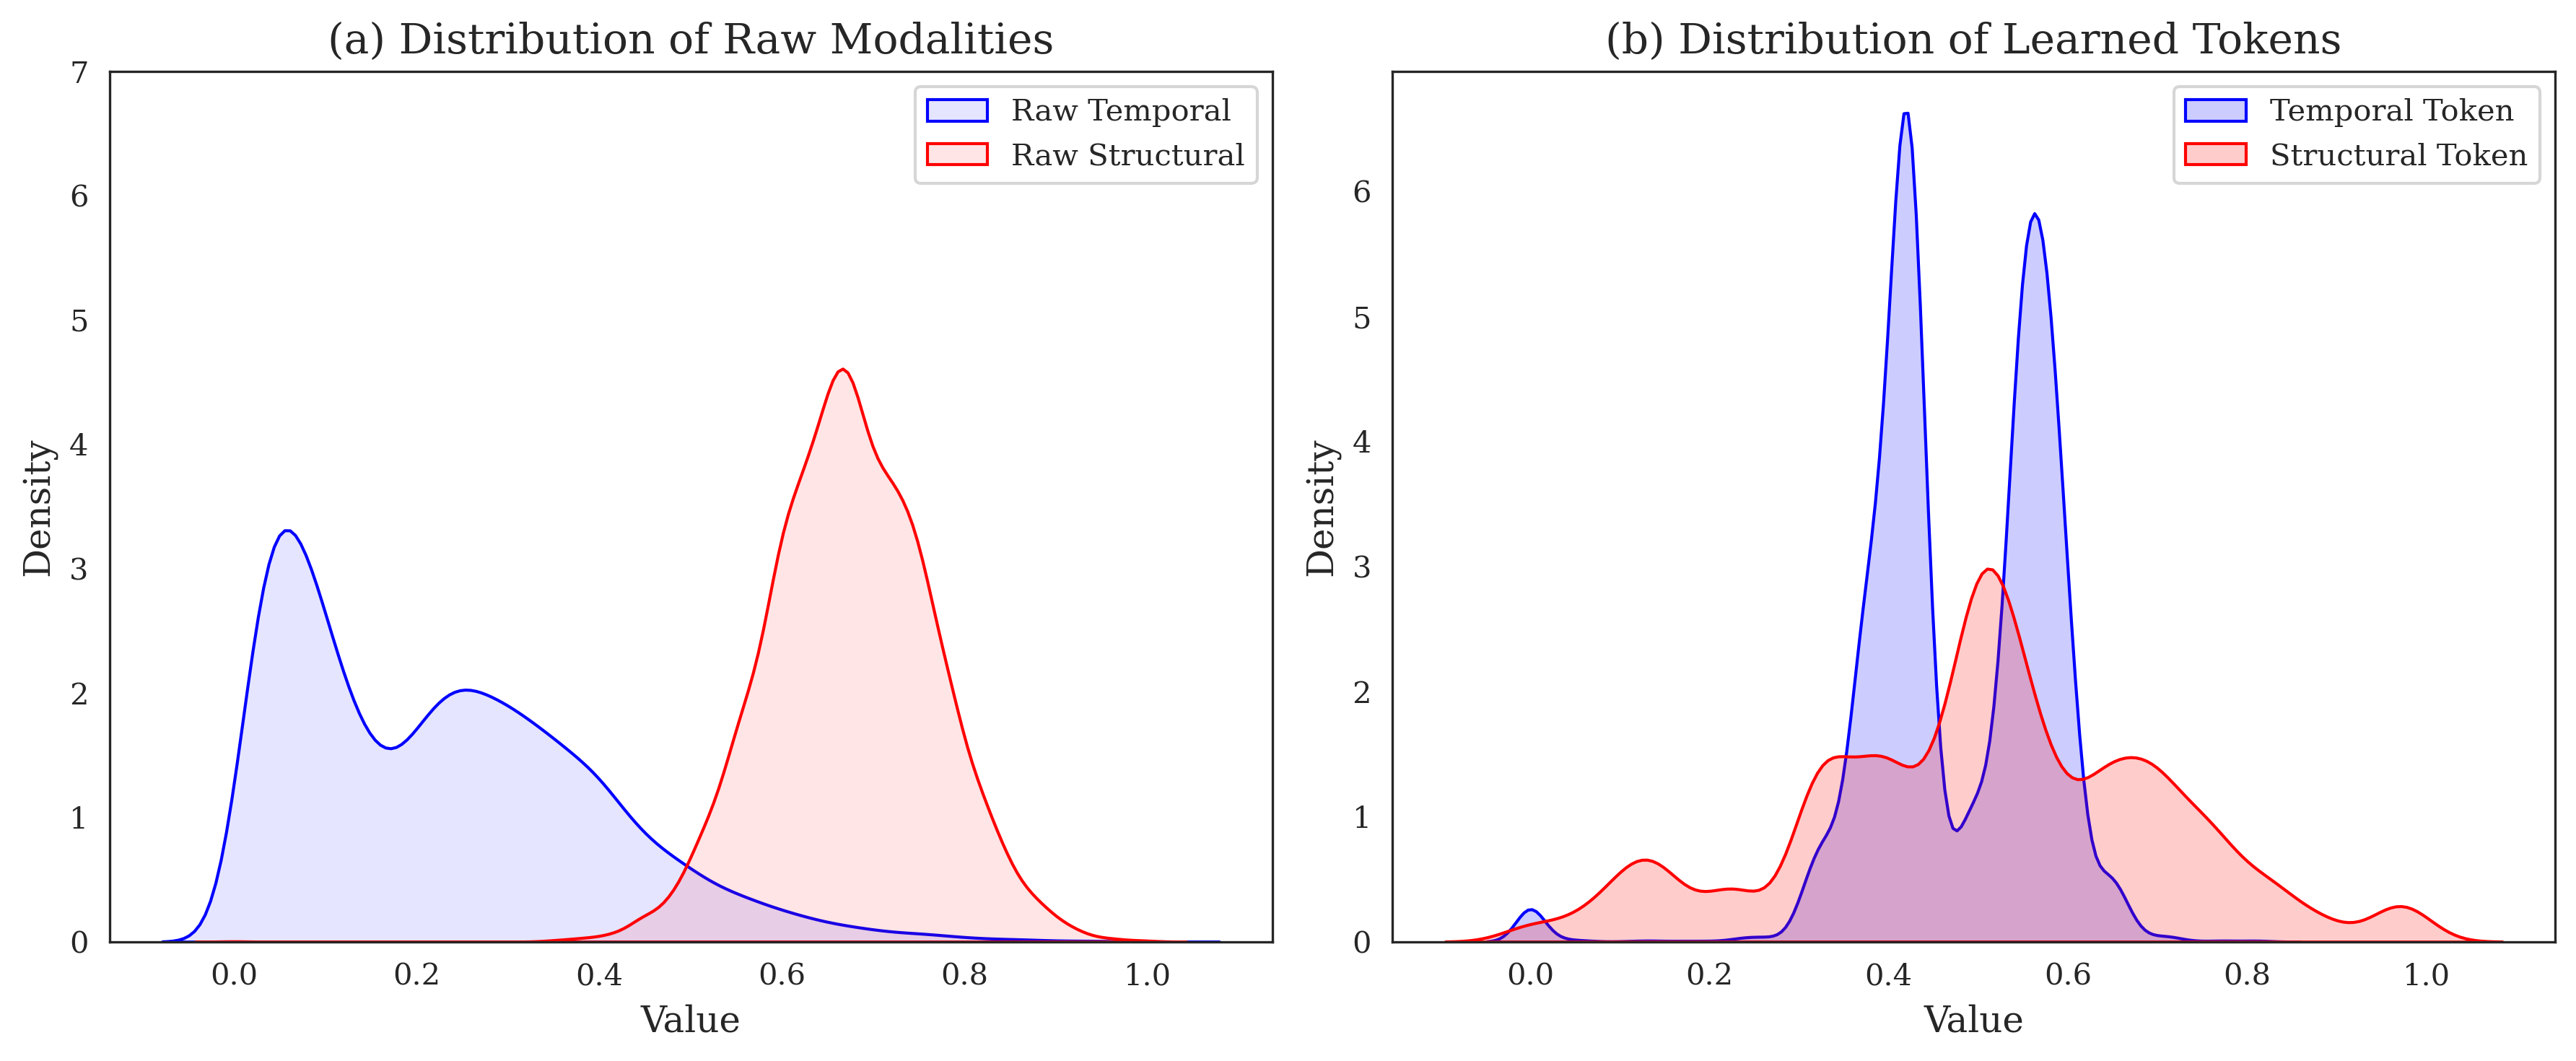

绘图完成！图片已保存至: aux-exp/RQ4/data/exp6_modality_alignment.png


In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 假设这些变量已经在前面的单元格加载好了
# raw_temp, raw_struct, token_temp, token_struct, save_dir = ... 

def clean_data(data_array):
    """
    【核心修复函数】
    将可能的 Object 数组（由多个 batch 组成）或高维数组
    强制展平为一维的 float 数组，供 Seaborn 绘图使用。
    """
    # 1. 确保输入是 numpy 数组
    if not isinstance(data_array, np.ndarray):
        data_array = np.array(data_array)
        
    # 2. 处理 Object 类型（通常是因为 Batch 大小不一致或 list 套 array 导致的）
    if data_array.dtype == 'object':
        try:
            # 尝试直接堆叠 (Stack)
            # 适用于 list 中每个元素 shape 相同的情况
            data_array = np.vstack(data_array)
        except Exception:
            # 如果失败（比如最后一个 batch 大小不一样），则暴力拼接
            # 先把每个元素展平，再拼起来
            data_array = np.concatenate([np.array(x).flatten() for x in data_array])
    
    # 3. 无论输入是 (N, 32) 还是 (N, 1)，统统展平成 1D 数组
    # 并强制转为 float 类型，防止 int 类型导致的某些兼容问题
    return data_array.flatten().astype(float)

def plot_kde_comparison():
    """
    绘制 Raw vs Token 的分布对比图
    """
    # --- 0. 数据清洗 (修复报错的关键步骤) ---
    print("正在清洗并展平数据...")
    # 使用全局变量中的数据进行清洗
    c_raw_temp = clean_data(raw_temp)
    c_raw_struct = clean_data(raw_struct)
    c_token_temp = clean_data(token_temp)
    c_token_struct = clean_data(token_struct)
    
    def normalize(arr):
        if len(arr) == 0: return arr
        _min, _max = np.min(arr), np.max(arr)
        if _max == _min: return np.zeros_like(arr)
        return (arr - _min) / (_max - _min)
    
    c_raw_temp = normalize(c_raw_temp)
    c_raw_struct = normalize(c_raw_struct)
    c_token_temp = normalize(c_token_temp)
    c_token_struct = normalize(c_token_struct)
    # --- 设置绘图风格 (模仿论文学术风) ---
    sns.set_style("white")
    plt.rcParams["font.family"] = "serif"  # 使用衬线字体，更像论文

    # 创建画布：1行2列
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

    # ================= 图 A: 原始特征分布 (Before) =================
    ax1 = axes[0]
    sample_size = 10000

    # 安全采样函数 (防止数据量小于 10000 时报错)
    def safe_sample(arr, n):
        if len(arr) == 0: return arr
        return np.random.choice(arr, min(len(arr), n), replace=False)

    # 从清洗后的数据中采样
    r_t_sample = safe_sample(c_raw_temp, sample_size)
    r_s_sample = safe_sample(c_raw_struct, sample_size)

    # 绘制 KDE
    sns.kdeplot(
        r_t_sample,
        ax=ax1,
        color="blue",
        linestyle="-",
        label="Raw Temporal",
        fill=True,
        alpha=0.1,
    )
    sns.kdeplot(
        r_s_sample,
        ax=ax1,
        color="red",
        linestyle="-",
        label="Raw Structural",
        fill=True,
        alpha=0.1,
    )

    ax1.set_title("(a) Distribution of Raw Modalities", fontsize=14)
    ax1.set_xlabel("Value", fontsize=12)
    ax1.set_ylabel("Density", fontsize=12)
    ax1.set_ylim(0, 7)
    ax1.legend(loc="upper right")

    # ================= 图 B: 学习后 Token 分布 (After) =================
    ax2 = axes[1]

    t_t_sample = safe_sample(c_token_temp, sample_size)
    t_s_sample = safe_sample(c_token_struct, sample_size)

    # 绘制 KDE (实线)
    sns.kdeplot(
        t_t_sample,
        ax=ax2,
        color="blue",
        linestyle="-",
        label="Temporal Token",
        fill=True,
        alpha=0.2,
    )
    sns.kdeplot(
        t_s_sample,
        ax=ax2,
        color="red",
        linestyle="-",
        label="Structural Token",
        fill=True,
        alpha=0.2,
    )

    ax2.set_title("(b) Distribution of Learned Tokens", fontsize=14)
    ax2.set_xlabel("Value", fontsize=12)
    ax2.set_ylabel("Density", fontsize=12)
    ax1.set_ylim(0, 7)
    ax2.legend(loc="upper right")

    # ================= 调整布局并保存 =================
    plt.tight_layout()

    # 确保保存目录存在
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        
    save_path = os.path.join(save_dir, "exp6_modality_alignment.png")
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    print(f"绘图完成！图片已保存至: {save_path}")
    # ... (后续 print 保持不变)

if __name__ == "__main__":
    plot_kde_comparison()